# 🚗🚚🚙🚍**CurvantML: Previsão de Condução de Risco em Curvas**

In [1]:
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import requests
import pyarrow
import folium
import math
import os

In [2]:
plt.rcParams.update({'font.size': 12}) # Ajusta o tamanho da fonte das imagens para 12

## 📂Carregando os dados tratados

In [30]:
df = pd.read_parquet('data/eletro_rjdf_serra.parquet')
df.head()

,lat,lon,vehicle_speed,accel_x,accel_y,accel_z,engine_rpm,mass_air_flow,absolute_throttle_pos,fuel_level,...,fuel_remaining,instant_fuel_economy,calculated_load_value,fuel_rail_pressure,accelerator_pos_d,accelerator_pos_e,time,accelerator_pedal_pos_d,accelerator_pedal_pos_e,fuel_rail_pressure_vacuum
0,-22.93086,-43.97891,68.0,0.363016,0.382445,-0.194902,2012.25,26.33,82.35294,70.19608,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-22.93093,-43.97915,70.0,-0.433087,0.174808,0.165078,2078.75,27.53,83.92157,70.19608,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-22.93096,-43.97928,71.0,-0.063610,0.018245,0.090633,2143.75,28.70,38.03922,72.54902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-22.93102,-43.97949,72.0,0.241251,0.234123,1.493305,2104.75,18.20,34.90196,72.54902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-22.93108,-43.97971,72.0,0.440336,-0.698661,-1.040103,1605.50,18.39,36.47059,72.54902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---



## **📈Detectar curvas**

A **Curvatura** $\kappa(t)$ de uma curva $C:{I} → \mathbb{R}^2$, $I\subset \mathbb{R}$ é dada por

$$\kappa(t) = \frac{|x'(t) y''(t) - y'(t) x''(t)|}{\left( (x'(t))^2 + (y'(t))^2 \right)^{3/2}}
$$

O **Filtro Gaussiano** realiza a convolução de um sinal com a função gaussiana, resultando em um novo sinal suavizado. A função gaussiana é definida como:

$$
G(x) = \frac{1}{\sqrt{2\pi \sigma^2}} e^{-\frac{x^2}{2\sigma^2}}
$$

onde:
- $ \sigma $ é o desvio padrão, que determina a largura da distribuição.

Para aplicar o filtro gaussiano a um sinal 1D $ f(t) $, a convolução é realizada da seguinte forma:

$$
g(t) = \int_{-\infty}^{\infty} f(\tau) G(t - \tau) d\tau
$$

onde:
- $ g(t) $ é o sinal suavizado.
- $ f(t) $ é o sinal original.
- $ G(t - \tau) $ é a função gaussiana centrada em $t$.

In [42]:
def detectar_curvas(df, sigma=2, limiar=30, limite_raio=50, name_traj=None):
    '''
    Função que detecta curvas em um trajeto e calcula o raio de curvatura.
    '''
    if name_traj is not None:
        df = df.query(f'id_route == "{name_traj}"').copy()

    df = df.copy()

    # Certifica que as colunas 'x' e 'y' existem no DataFrame
    if 'x' not in df.columns or 'y' not in df.columns:
      print(df.id_route.unique()[0])

    df_unicos = df.drop_duplicates(subset=['lat', 'lon', 'vehicle_speed'], keep='last').reset_index(drop=True)

    x = df_unicos.x
    y = df_unicos.y
    t = np.arange(len(x))

    # interpolação cúbica
    cs = make_interp_spline(t, np.c_[x, y], k=3)
    t_fino = np.linspace(0, len(x) - 1, len(x))
    x_interp, y_interp = cs(t_fino).T

    # derivadas de x e y em relação a t
    dxdt = np.gradient(x_interp, t_fino)
    dydt = np.gradient(y_interp, t_fino)

    # segundas derivadas de x e y em relação a t
    ddx = np.gradient(dxdt, t_fino)
    ddy = np.gradient(dydt, t_fino)

    denom = np.power(dxdt**2 + dydt**2, 3 / 2)
    with np.errstate(invalid='ignore', divide='ignore'):
        curvatura = np.where(denom > 0, np.abs(dxdt * ddy - dydt * ddx) / denom, 0.0)
    curvatura_suave = gaussian_filter1d(curvatura, sigma=sigma) # suaviza a curvatura para evitar falsos positivos
    sinal_curvatura = np.sign(gaussian_filter1d(dxdt * ddy - dydt * ddx, sigma=2))

    # raio de curvatura
    raio_curvatura = np.zeros_like(curvatura_suave)
    with np.errstate(divide='ignore', invalid='ignore'):
        raio_curvatura = np.where(curvatura_suave != 0, 1 / curvatura_suave, np.inf)

    # limiar
    limiar_curvatura = np.percentile(curvatura_suave, limiar)
    pontos_curva = (curvatura_suave > limiar_curvatura) & (raio_curvatura < limite_raio)

    

    # calcular a distância acumulada
    distancia_acumulada = np.zeros(len(x_interp))
    distancia_acumulada[1:] = np.cumsum(np.sqrt(np.diff(x_interp)**2 + np.diff(y_interp)**2))

    # adiciona as variáveis ao DataFrame
    df_unicos = df_unicos.assign(
        raio_curvatura=raio_curvatura,
        curvatura=curvatura_suave,
        curva=pontos_curva,
        sinal_curvatura=sinal_curvatura,
        distancia_acumulada=distancia_acumulada
        )

    return df_unicos

### Funções para Plotagem

In [33]:
def plot_trajeto_com_curvatura(df, sigma=2, limiar=30, limite_raio=50, save_fig=False, name_file=None):
    """
    Função para plotar o trajeto completo com as curvas detectadas e os raios de curvatura.
    Considera pontos repetidos do DataFrame `df_final`.
    """

    df_final = detectar_curvas(df, sigma=sigma, limiar=limiar, limite_raio=limite_raio)

    x = df_final['x']
    y = df_final['y']
    pontos_curva = df_final['curva']
    raio_curvatura = df_final['raio_curvatura']
    sinal_curvatura = df_final['sinal_curvatura']
    dxdt = np.gradient(x)  # Derivada aproximada para direção x
    dydt = np.gradient(y)  # Derivada aproximada para direção y

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot do trajeto completo
    ax.plot(x, y, color='blue', linewidth=2, label='Trajeto Completo')

    # Marca os pontos de curva detectados
    ax.scatter(x[pontos_curva], y[pontos_curva], color='red', s=30, label='Curvas Detectadas')

    # Adiciona raios de curvatura menores que o limite
    for i in range(len(x)):
        if raio_curvatura[i] < limite_raio:
            normal_x = -dydt[i]
            normal_y = dxdt[i]
            norma = np.sqrt(normal_x**2 + normal_y**2)
            if norma != 0:
                normal_x /= norma
                normal_y /= norma
            normal_x *= sinal_curvatura[i]
            normal_y *= sinal_curvatura[i]
            raio_ponto_x = x[i] + normal_x * raio_curvatura[i]
            raio_ponto_y = y[i] + normal_y * raio_curvatura[i]
            ax.plot([x[i], raio_ponto_x], [y[i], raio_ponto_y], color='green', linewidth=1)

    ax.set_title(f'Trajeto Completo com Curvas e Raios de Curvatura (limite < {limite_raio} metros)', fontsize=14)
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.legend()
    ax.grid()

    if save_fig:
        plt.savefig(f'{name_file}.pdf', bbox_inches='tight', dpi=300)
    plt.show()

In [34]:
def plot_trip_folium(df, sigma=2, limiar=30, limite_raio=50, name_traj=None):
    """
    Plota o trajeto completo com curvas detectadas e raios de curvatura em um mapa Folium.

    Args:
        df (pd.DataFrame): DataFrame contendo os dados do trajeto com 'lat' e 'lon'.
        sigma (int): Parâmetro sigma para o filtro gaussiano.
        limiar (int): Limiar percentil para detecção de curvas (0-100).
        limite_raio (int): Limite do raio de curvatura para plotagem das linhas de raio.
        name_traj (str, optional): Nome do trajeto específico a ser plotado. Se None, usa o df completo.

    Returns:
        folium.Map: Objeto Folium Map com o trajeto plotado.
    """

    df_final = detectar_curvas(df, sigma=sigma, limiar=limiar, limite_raio=limite_raio, name_traj=name_traj)

    if df_final.empty or df_final[['lat', 'lon']].isnull().all().any() or len(df_final) < 2:
        print(f"Não há dados suficientes ou válidos para plotar o trajeto {name_traj if name_traj else 'completo'}.")
        return None

    # Pegar o primeiro ponto válido para centrar o mapa inicialmente
    first_valid_point = df_final.dropna(subset=['lat', 'lon']).iloc[0]
    map_center = [first_valid_point['lat'], first_valid_point['lon']]
    m = folium.Map(location=map_center, zoom_start=15)

    # Adicionar o trajeto completo como uma linha
    folium.PolyLine(locations=df_final[['lat', 'lon']].values.tolist(), color='blue', weight=3, opacity=0.7,
                    tooltip=f"Trajeto: {df_final['id_route'].iloc[0]}").add_to(m)

    # Filtrar pontos de curva detectados
    curve_points = df_final[df_final['curva'] == True].dropna(subset=['lat', 'lon'])

    for idx, row in curve_points.iterrows():
        # Adicionar marcadores para pontos de curva
        popup_text = f"Curva<br>Curvatura: {row['curvatura']:.2e}<br>Raio: {row['raio_curvatura']:.2f} m"
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=3,
            color='red',
            fill=True,
            fill_color='red',
            fill_opacity=0.7,
            popup=popup_text
        ).add_to(m)

        # Adicionar linha indicando o raio de curvatura para raios pequenos
        if row['raio_curvatura'] < limite_raio and not pd.isna(row['raio_curvatura']) and row['raio_curvatura'] != np.inf:
            # Para Folium, é mais fácil simplesmente marcar o ponto da curva
            # e, se quisermos visualizar o raio, teríamos que calcular o ponto final do vetor do raio.
            # Isso exige a direção do movimento no ponto da curva.
            # Para simplificar, focaremos nos CircleMarkers para a visualização inicial.
            pass # Deixando a complexidade da linha do raio de fora por enquanto para manter a simplicidade.

    # Ajustar o zoom para cobrir todo o trajeto
    min_lat, max_lat = df_final['lat'].min(), df_final['lat'].max()
    min_lon, max_lon = df_final['lon'].min(), df_final['lon'].max()
    m.fit_bounds([[min_lat, min_lon], [max_lat, max_lon]])

    return m

In [35]:
df_sample = [df.query(f'id_route == "{trip}"') for trip in list(df.id_route.unique())[0:4]]

In [36]:
data_curves = []
for dt in df_sample:
  data_curve_traj = detectar_curvas(dt, sigma = 2, limiar = 30)
  data_curves += [data_curve_traj]
dfs_curves = pd.concat(data_curves)


Matplotlib


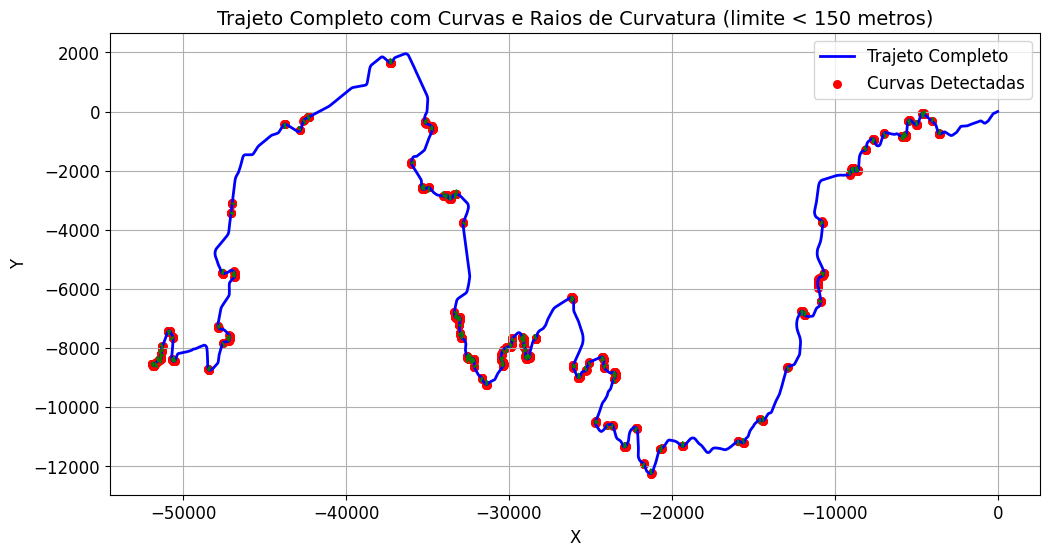

In [62]:
print("Matplotlib")
plot_trajeto_com_curvatura(df_sample[0], sigma=2, limiar=80, limite_raio=150)

#print("\nFolium:")
#mapa = plot_trip_folium(df_sample[0], sigma=3, limiar=60, limite_raio=300)
#mapa.save("mapa.html")

In [49]:
Soma = 0
for traj in dfs_curves.id_route.unique():
  df = dfs_curves.query(f'id_route == "{traj}"')
  curva = df['curva'].tolist()

  N = 0
  in_true_sequence = False

  for valor in curva:
      if valor and not in_true_sequence:
          N += 1
          in_true_sequence = True
      elif not valor:
          in_true_sequence = False

  Soma += N

  print(f"Número de Curvas: {traj} - {N}")

print(f"Soma: {Soma}")

Número de Curvas: obd-15-spin-trajeto-t1 - 150
Número de Curvas: obd-16-van-circuito-t1 - 35
Número de Curvas: obd-16-van-circuito-t2 - 86
Número de Curvas: obd-16-van-trajeto-t3 - 13
Número de Curvas: obd-17-spin-trajeto-t1 - 12
Número de Curvas: obd-17-spin-trajeto-t2 - 12
Número de Curvas: obd-18-van-trajeto-t2 - 25
Número de Curvas: obd-18-van-trajeto-t3 - 107
Número de Curvas: tabela_final-16-spin-circuito-t1 - 10
Número de Curvas: tabela_final-16-spin-trajeto-t2 - 25
Número de Curvas: tabela_final-16-van-trajeto-t1 - 72
Número de Curvas: tabela_final-16-van-trajeto-t2 - 76
Número de Curvas: tabela_final-18-van-trajeto-t1 - 60
Número de Curvas: tabela_final-19-spin-trajeto-t1 - 212
Número de Curvas: CSVLog_20240920_044510 - 125
Número de Curvas: CSVLog_20240920_062459 - 81
Número de Curvas: CSVLog_20240920_073017 - 151
Número de Curvas: CSVLog_20240920_090744 - 24
Número de Curvas: CSVLog_20240920_093107 - 124
Número de Curvas: CSVLog_20240920_115708 - 207
Número de Curvas: CSVLog

---

## 🚨**Condução de risco no contexto veicular**

**DEFINIÇÕES DE COMPORTAMENTOS DE CONDUÇÃO PERIGOSOS**

(_Li et al. (2016) Dangerous driving behavior detection using smartphone sensors_)

O objetivo é reconhecer comportamentos de condução perigosos. Três tipos de comportamento de risco típico são selecionados e definidos:

1. Acelerar ou desacelerar anormalmente: aumentar ou diminuir
a velocidade do veículo bruscamente em um curto período, como a
variância da velocidade ser maior que 30 km/h em 10 segundos.

2. Direção: virar à esquerda ou à direita mais de 0,7 rad a uma
velocidade acima de 30 km/h, o que pode causar capotamento.
Vamos

3. Zigue-zague: dirigir em forma de S, o veículo
muda de faixa com muita frequência, o que pode causar engarrafamentos
ou arranhões no veículo.

`Aceleração centripeta` e `Aceleração Absoluta`

In [50]:
dfs_curves['ctp_accel'] = (dfs_curves['vehicle_speed']/3.6)**2/dfs_curves['raio_curvatura'] # m/s**2
dfs_curves['abs_accel'] = np.sqrt(dfs_curves['accel_x']**2 + dfs_curves['accel_y']**2)

In [51]:
# parâmetros perigosos (Li et al. (2016)-Dangerous_driving_behavior_detection_using_smartphone_sensors)
var_velocidade_max = 15  # km/h em 5 segundos
angulo_max_direcao = .7  # rad
velocidade_max_direcao = 30  # km/h
velocidade_min_zigue_zague = 30  # km/h

def calcular_bearing(lat1, lon1, lat2, lon2):
    """
    Calcula o ângulo de direção entre dois pontos (lat1, lon1) e (lat2, lon2) usando a fórmula de bearing.
    Retorna o ângulo em radianos.
    """
    # graus para radianos
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    theta = np.arctan2(x, y)

    # normaliza para o intervalo [0, 360)
    bearing = np.degrees(theta)
    bearing = (bearing + 360) % 360
    return bearing

# 1 aceleração/desaceleração anormal
def detectar_aceleracao_anormal(var_velocidade):
    if var_velocidade > var_velocidade_max:
        return True
    return False

# 2 direção
def detectar_direcao_perigosa(velocidade, theta):
    # Assumindo que a mudança de curvatura seja proporcional à mudança de ângulo de direção
    if velocidade > velocidade_max_direcao and np.abs(theta) < angulo_max_direcao:
        return True
    return False

# 3 zigue zague
def calcular_aceleracao_lateral(aceleracao_x, aceleracao_y, bearing):
    return aceleracao_x * np.sin(np.radians(bearing)) + aceleracao_y * np.cos(np.radians(bearing))

def detectar_zigue_zague(janela):
    limiar_mudanca_bearing = 15  # graus
    limiar_aceleracao_lateral = 0.3  # m/s²
    zigue_zague = False
    contador_mudancas = 0  # Contador de mudanças de direção
    latitudes = janela['lat'].tolist()
    longitudes = janela['lon'].tolist()
    aceleracao_x = janela['accel_x'].tolist()
    aceleracao_y = janela['accel_y'].tolist()
    janela_tempo = len(janela)
    ctp_accel = janela['ctp_accel'].tolist()

    # Calcula os ângulos de bearing para todos os pontos
    bearing_angles = []
    for i in range(1, len(latitudes)):
        bearing = calcular_bearing(latitudes[i-1], longitudes[i-1], latitudes[i], longitudes[i])
        bearing_angles.append(bearing)
    bearing_angles = np.array(bearing_angles)

    for i in range(1, len(bearing_angles)):
        mudanca_bearing = abs(bearing_angles[i] - bearing_angles[i-1])
        #aceleracao_lateral = calcular_aceleracao_lateral(aceleracao_x[i], aceleracao_y[i], bearing_angles[i])
        aceleracao_lateral = ctp_accel[i]

        # Verifica se há uma mudança brusca na direção e alta aceleração lateral
        if mudanca_bearing > limiar_mudanca_bearing and abs(aceleracao_lateral) > limiar_aceleracao_lateral:
            contador_mudancas += 1  # Incrementa o contador de mudanças

            # Verifica se houve 3 mudanças na janela de tempo considerada
            if contador_mudancas >= 3:
                zigue_zague = True
                break  # Sai do loop se zigue-zague for detectado

        # Reinicia o contador se a janela de tempo for excedida
        if i >= janela_tempo:
            contador_mudancas = 0

    return zigue_zague

In [52]:
def detectar_conducao_perigosa(df, janela_tempo=10):
    """
    Função que detecta comportamentos de condução perigosos.
    """
    resultados = []
    inicio = df['time_sec'].min()  # tempo inicial
    fim = df['time_sec'].max()  # tempo final

    t = inicio
    id = 1
    while t + janela_tempo <= fim:
        janela = df[(df['time_sec'] >= t) & (df['time_sec'] < t + janela_tempo)]
        latitudes = janela['lat'].tolist()
        longitudes = janela['lon'].tolist()

        if len(janela) < 2:  # Poucos dados na janela
            t += janela_tempo
            continue
        # 1. aceleração ou desaceleração anormal
        var_velocidade = janela['vehicle_speed'].diff().abs().sum()
        aceleracao_anormal = detectar_aceleracao_anormal(var_velocidade)

        # 2. direção perigosa
        thetas = []
        for i in range(1, len(janela)):
          bearing = calcular_bearing(latitudes[i-1], longitudes[i-1], latitudes[i], longitudes[i])
          thetas.append(bearing)
        thetas = np.array(thetas)
        theta_direcao = np.abs(np.sum(np.diff(thetas)))
        velocidade_media = janela['vehicle_speed'].mean()
        direcao_perigosa = detectar_direcao_perigosa(velocidade_media, theta_direcao)

        # 3. zigue-zague
        zigue_zague = detectar_zigue_zague(janela)

        conducao = 'Perigosa' if aceleracao_anormal or direcao_perigosa or zigue_zague else 'Segura'
        janela = janela.copy()
        janela['conducao'] = conducao
        janela['aceleracao_anormal'] = aceleracao_anormal
        janela['direcao_perigosa'] = direcao_perigosa
        janela['zigue_zague'] = zigue_zague
        janela['theta_direcao'] = theta_direcao
        janela['id_janela'] = id
        id += 1

        resultados.append(janela)

        t += janela_tempo

    return pd.concat(resultados, ignore_index=True)

In [53]:
df_analysis = []

for traj in dfs_curves.id_route.unique():
  df = dfs_curves.query(f'id_route == "{traj}"')
  df_analysis += [detectar_conducao_perigosa(df, janela_tempo = 10)]

df_analysis = pd.concat(df_analysis)

In [54]:
def plotar_trajeto_conducao(df, tipo='conducao'):
    """
    Plota o trajeto com pontos x e y, destacando os trechos onde a condução foi perigosa.
    """
    # Filtra os pontos onde a condução foi perigosa
    if tipo == 'conducao':
        pts_perigosos = df[df[tipo] == 'Perigosa']
    else:
      pts_perigosos = df[df[tipo] == True]

    fig, ax = plt.subplots(ncols=2, figsize=(20, 4))

    # Plota o trajeto completo
    ax[0].plot(-df['x'], -df['y'], label='Trajeto', color='blue', alpha=0.5)
    ax[1].plot(-df['x'], df['vehicle_speed'],label='vel')

    # Plota os pontos onde a condução foi perigosa
    if not pts_perigosos.empty:
        ax[0].scatter(-pts_perigosos['x'], -pts_perigosos['y'],
                    color='red', label=f'Condução Perigosa ({tipo})', s=50, marker='.')

    name_traj = df['id_route'].iloc[0]
    ax[0].set_title(f'Trajeto com Condução Perigosa Destacada\n{name_traj}')
    ax[0].set_xlabel('Posição X')
    ax[0].set_ylabel('Posição Y')
    ax[1].set_xlabel('Posição X')
    ax[1].set_ylabel('v')
    ax[0].legend()
    ax[0].grid(True)
    ax[1].grid()
    ax[1].legend()
    plt.show()

In [55]:
tjs = df_analysis.id_route.unique()
for traj in tjs:

  # trajetos ruins:
  # obd-17-van-circuito-t1
  # obd-17-van-circuito-t2

  dteste = df_analysis.query(f'id_route == "{traj}"')
  plotar_trajeto_conducao(dteste)

Output hidden; open in https://colab.research.google.com to view.

In [56]:
total_time = 0
for traj in df_analysis.id_route.unique():
  df = df_analysis.query(f'id_route == "{traj}"')
  print(df.time_sec.max()/60/60,traj)
  total_time += df.time_sec.max()

print(f'Tempo Total: {total_time/(60*60)}')

1.7252947222222221 obd-15-spin-trajeto-t1
0.863695 obd-16-van-circuito-t1
1.2976822222222222 obd-16-van-circuito-t2
0.20293361111111113 obd-16-van-trajeto-t3
0.12088638888888889 obd-17-spin-trajeto-t1
0.10279861111111112 obd-17-spin-trajeto-t2
0.3887216666666667 obd-18-van-trajeto-t2
2.388967777777778 obd-18-van-trajeto-t3
0.35023499999999996 tabela_final-16-spin-circuito-t1
0.3635627777777778 tabela_final-16-spin-trajeto-t2
23.888056944444443 tabela_final-16-van-trajeto-t1
1.7170363888888889 tabela_final-16-van-trajeto-t2
1.4415483333333332 tabela_final-18-van-trajeto-t1
3.432377777777778 tabela_final-19-spin-trajeto-t1
1.1211991666666667 CSVLog_20240920_044510
0.6926452777777778 CSVLog_20240920_062459
1.5506633333333333 CSVLog_20240920_073017
0.2375 CSVLog_20240920_090744
1.36076 CSVLog_20240920_093107
1.891075 CSVLog_20240920_115708
1.4972375000000002 CSVLog_20240920_135802
0.3247186111111111 CSVLog_20240921_070315
1.5347244444444443 CSVLog_20240921_081801
0.7850066666666666 CSVLog_

---

### ✨APLICANDO OS ALGORITIMOS DE ML

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
from sklearn.metrics import f1_score
from sklearn import metrics
import itertools

In [58]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM

## 📥📤Detecção de condução perigosa em **curvas**

In [59]:
def identificar_trechos_curvos(df):
    """
    Identifica os trechos de curva no DataFrame com base na coluna 'curva'.
    o df deve ter a coluna id_route (id do trajeto).
    Retorna um DataFrame com uma nova coluna 'trecho_curvo' que identifica cada trecho.
    """
    df_trechos = pd.DataFrame()
    df_trechos['trecho_curvo'] = 0

    # contador para trechos curvos
    trecho_id = 1
    for traj in df.id_route.unique():

        df_traj = df.query(f'id_route == "{traj}"').copy()
        df_traj.reset_index(drop=True, inplace=True)

        em_trecho_curvo = False
        for i in range(len(df_traj)):

            if df_traj['curva'].iloc[i]:  # Se é uma curva
                if not em_trecho_curvo:
                    em_trecho_curvo = True  # Começa um novo trecho
                df_traj.at[i, 'trecho_curvo'] = trecho_id

            else:
                if em_trecho_curvo:
                    trecho_id += 1
                    em_trecho_curvo = False  # Sai do trecho curvo

        df_trechos = pd.concat([df_trechos, df_traj])

    df_trechos.reset_index(drop=True, inplace=True)

    return df_trechos  # Retorna o DataFrame com a nova coluna 'trecho_curvo'

📊Média de algumas variáveis por trajeto

In [60]:
ds = identificar_trechos_curvos(df_analysis)

def calcular_estatisticas_por_trajeto(df):
    # Definindo as variáveis de interesses
    vars_interesse = {
        'vehicle_speed': 'v',
        'theta_direcao': 'theta',
        'accel_x': 'a_x',
        'accel_y': 'a_y',
        'accel_z': 'a_z',
        }

    estatisticas = []

    # Iterando por cada trajeto (id_route)
    for id_route_atual, trajeto in df.groupby('id_route'):
        estatisticas_trajeto = {
            'id_trajeto': id_route_atual,
            'numb_curve': len(trajeto.trecho_curvo.unique())-1
            }

        for var, traducao in vars_interesse.items():
            estatisticas_trajeto[f'{traducao}'] = round(trajeto[var].mean(), 2)
        estatisticas.append(estatisticas_trajeto)

    df_estatisticas_trajetos = pd.DataFrame(estatisticas)

    return df_estatisticas_trajetos

In [61]:
rs = calcular_estatisticas_por_trajeto(ds)
rs.to_latex('estatisticas_por_trajeto.tex', index=True, float_format="%.2f") # isso gera o arquivo LaTeX

📥*Features*

In [62]:
def extrair_features(data, janela_tempo=10):
    """
    Extrai as features de uma janela de tempo antes da curva,
    considerando trajetos individuais (id_route).
    """
    dados_janela = pd.DataFrame()
    df = data.copy()
    df['conducao'] = df['conducao'].map({'Perigosa': 1, 'Segura': 0})
    df = df.sort_values(by=['id_route', 'time_sec'])

    vars = ['vehicle_speed','engine_rpm', 'accel_x', 'accel_y']

    for (id_route_atual, trecho_curvo), curva in df.groupby(['id_route', 'trecho_curvo']):
        if len(curva) > 2:  # Considera trechos com pelo menos 3 pontos
            inicio_curva = curva['time_sec'].min()
            fim_curva = curva['time_sec'].max()

            # Seleciona a janela anterior à curva dentro do mesmo trajeto
            janela = df[(df['id_route'] == id_route_atual) &
                        (df['time_sec'] < inicio_curva) &
                        (df['time_sec'] >= inicio_curva - janela_tempo)].copy()

            if not janela.empty:
                # Criação do DataFrame com as estatísticas da janela
                df_seg = pd.DataFrame({
                    'time_inicio': [janela['time_sec'].min()],
                    'time_fim': [janela['time_sec'].max()],
                    'id_route': [id_route_atual],
                    'id_trecho_curvo': [trecho_curvo]
                    })

                # Extração de médias, desvios padrões, medianas e novas features para as variáveis
                for var in vars:
                    df_seg[var + '_mean'] = janela[var].mean()
                    df_seg[var + '_std'] = janela[var].std()
                    df_seg[var + '_median'] = janela[var].median()
                    df_seg[var + '_max'] = janela[var].max()
                    df_seg[var + '_min'] = janela[var].min()

                ## distancia à curva
                df_seg['distance_car_curve'] = janela['distancia_acumulada'].max() - janela['distancia_acumulada'].min()

                ## Outras features de eventos perigosos
                n_perigo_acc_anormal_janela = janela['aceleracao_anormal'].sum()
                n_perigo_dir_perigosa_janela = janela['direcao_perigosa'].sum()
                n_perigo_zigue_zague_janela = janela['zigue_zague'].sum()
                df_seg['n_perigo_acc_anormal_janela'] = n_perigo_acc_anormal_janela
                df_seg['n_perigo_dir_perigosa_janela'] = n_perigo_dir_perigosa_janela
                df_seg['n_perigo_zigue_zague_janela'] = n_perigo_zigue_zague_janela

                # Verifica se há pelo menos 2 pontos "Perigosos"
                n_perigoso = curva['conducao'].sum()
                n_perigo_a = curva['aceleracao_anormal'].sum()
                n_perigo_d = curva['direcao_perigosa'].sum()
                n_perigo_z = curva['zigue_zague'].sum()

                manobra = 1 if n_perigoso >= 2 else 0
                manobra_accel_perigo = 1 if n_perigo_a >= 2 else 0
                manobra_dir_perigosa = 1 if n_perigo_d >= 2 else 0
                manobra_zigue_zague = 1 if n_perigo_z >= 2 else 0

                df_seg['manobra'] = manobra  # esse é o target
                df_seg['manobra_accel_perigo'] = manobra_accel_perigo
                df_seg['manobra_dir_perigosa'] = manobra_dir_perigosa
                df_seg['manobra_zigue_zague'] = manobra_zigue_zague

                # Adiciona os dados ao DataFrame final
                dados_janela = pd.concat([dados_janela, df_seg])

            else:
                print(f"Janela vazia para {id_route_atual} e trecho {trecho_curvo}")

    return dados_janela.reset_index(drop=True)

In [63]:
ds[['aceleracao_anormal', 'direcao_perigosa', 'zigue_zague']] = ds[['aceleracao_anormal', 'direcao_perigosa', 'zigue_zague']].astype(int)

In [64]:
dfs_bons = df_analysis.copy()
dfs_bons = identificar_trechos_curvos(dfs_bons)

In [65]:
teste_com_trechos_bons = extrair_features(dfs_bons)

Janela vazia para CSVLog_20240920_044510 e trecho 882.0
Janela vazia para CSVLog_20240920_073017 e trecho 1086.0
Janela vazia para CSVLog_20240920_090744 e trecho 1236.0
Janela vazia para CSVLog_20240920_093107 e trecho 1259.0
Janela vazia para CSVLog_20240920_115708 e trecho 1382.0
Janela vazia para CSVLog_20240920_135802 e trecho 1588.0
Janela vazia para CSVLog_20240921_070315 e trecho 1713.0
Janela vazia para CSVLog_20240921_081801 e trecho 1728.0
Janela vazia para CSVLog_20240921_100600 e trecho 1831.0
Janela vazia para CSVLog_20240921_114232 e trecho 1910.0
Janela vazia para CSVLog_20240921_133001 e trecho 1921.0
Janela vazia para CSVLog_20240922_145422 e trecho 1931.0
Janela vazia para CSVLog_20240922_153409 e trecho 1957.0
Janela vazia para CSVLog_20240922_180758 e trecho 1961.0
Janela vazia para CSVLog_20240922_195109 e trecho 2083.0
Janela vazia para CSVLog_20240922_195916 e trecho 2089.0
Janela vazia para CSVLog_20240927_041758 e trecho 2418.0
Janela vazia para CSVLog_2024092

In [66]:
tab_result = pd.DataFrame(
    {
        'Manobra': ['Segura', 'Perigosa'],
        'Conducão': [teste_com_trechos_bons.manobra.value_counts()[0],
                     teste_com_trechos_bons.manobra.value_counts()[1]],
        'Aceleração anormal': [teste_com_trechos_bons.manobra_accel_perigo.value_counts()[0],
                               teste_com_trechos_bons.manobra_accel_perigo.value_counts()[1]],
        'Direção perigosa': [teste_com_trechos_bons.manobra_dir_perigosa.value_counts()[0],
                             teste_com_trechos_bons.manobra_dir_perigosa.value_counts()[1]
                             ],
        'Zigue-zague': [teste_com_trechos_bons.manobra_zigue_zague.value_counts()[0],
                        teste_com_trechos_bons.manobra_zigue_zague.value_counts()[1]]
    }
)

In [67]:
tab_result.set_index('Manobra', inplace=True)
tab_result

,Conducão,Aceleração anormal,Direção perigosa,Zigue-zague
Manobra,,,,
Segura,1146,1942,2126,2618
Perigosa,1983,1187,1003,511


Lembra que a `conducao` é `True` (perigosa) se `aceleracao anormal` é `True` **OU** `direção` é `True` **OU** `zigue-zague` é `True`.

In [ ]:
teste_com_trechos_bons.loc[:,['manobra_accel_perigo', 'manobra_dir_perigosa', 'manobra_zigue_zague']].value_counts().to

manobra_accel_perigo  manobra_dir_perigosa  manobra_zigue_zague
0                     0                     0                      606
                      1                     0                       90
                      0                     1                       87
1                     0                     0                       24
                                            1                       21
                      1                     0                        8
0                     1                     1                        7
1                     1                     1                        3
Name: count, dtype: int64

In [68]:
tab_result.to_latex('tab_result.tex', index=True)

📤Modelos

In [69]:
def aplicar_modelos_ml(df, plot_cm=False):
    """
    Aplica modelos de Machine Learning para classificação de manobras.
    """
    # Variáveis principais e outras features
    vars = ['vehicle_speed', 'engine_rpm', 'accel_x', 'accel_y']
    other_vars = ['n_perigo_acc_anormal_janela', 'n_perigo_dir_perigosa_janela', 'n_perigo_zigue_zague_janela',
                  'distance_car_curve']

    features = ([vi + '_median' for vi in vars] +
                [vj + '_std' for vj in vars] +
                [vk + '_mean' for vk in vars] +
                other_vars)

    X = df[features]
    y = df['manobra']

    smote = SMOTE(random_state=42)
    X, y = smote.fit_resample(X, y)

    # Escalando os dados
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Dividindo em treino e teste
    rdm_state = 42
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=rdm_state)

    # Modelos de Machine Learning
    modelos = {
        "Regressão Logística": LogisticRegression(random_state=rdm_state),
        "SVM": svm.SVC(kernel='linear', random_state=rdm_state),
        "Árvore de Decisão": DecisionTreeClassifier(random_state=rdm_state),
        "Floresta Aleatória": RandomForestClassifier(random_state=rdm_state),
        "Rede Neural (MLP)": MLPClassifier(activation='relu', learning_rate='constant', solver='adam',
                                           hidden_layer_sizes=(128, 64), max_iter=2000, random_state=rdm_state,
                                           )
            }

    resultados = []

    for nome, modelo in modelos.items():
        # Validação cruzada no conjunto de dados
        scores = cross_val_score(modelo, X_scaled, y, cv=5)

        # Treinando o modelo no conjunto de treino
        modelo.fit(X_train, y_train)

        # Predizendo no conjunto de teste
        y_pred = modelo.predict(X_test)

        # Armazenando os resultados da validação cruzada
        for fold, score in enumerate(scores):
            resultados.append({
                "Bloco": f"Bloco {fold + 1}",
                "Classificador": nome,
                "Acurácia": score
            })

        # Matriz de confusão e acurácia
        cm = confusion_matrix(y_test, y_pred)
        accuracy = accuracy_score(y_test, y_pred)
        print(f"{nome} - Acurácia: {accuracy}")

        if plot_cm: # plot cm
            plt.figure(figsize=(6, 4))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['Segura', 'Risco'],
                        yticklabels=['Segura', 'Risco'])
            plt.title(f'{nome}')
            plt.ylabel('Real')
            plt.xlabel('Prevista')
            plt.savefig(f'matriz_confusao_{nome}.pdf', bbox_inches='tight')
            plt.show()

    # resultados finais
    df_resultados = pd.DataFrame(resultados)
    df_resultados_pivot = df_resultados.pivot(index='Bloco', columns='Classificador', values='Acurácia')
    df_resultados_pivot.to_latex('ml_resultados.tex', float_format="%.2f")

    return df_resultados_pivot.reset_index()

In [70]:
df_ml = teste_com_trechos_bons.copy()

Regressão Logística - Acurácia: 0.66890756302521


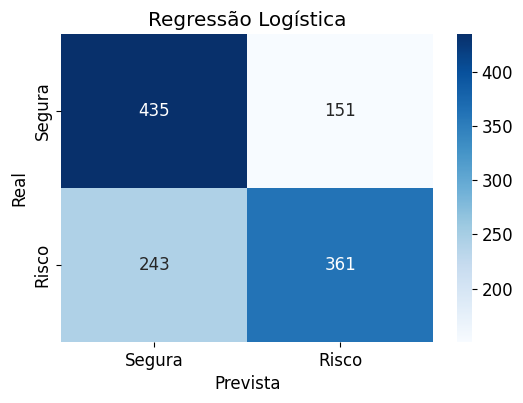

SVM - Acurácia: 0.6663865546218487


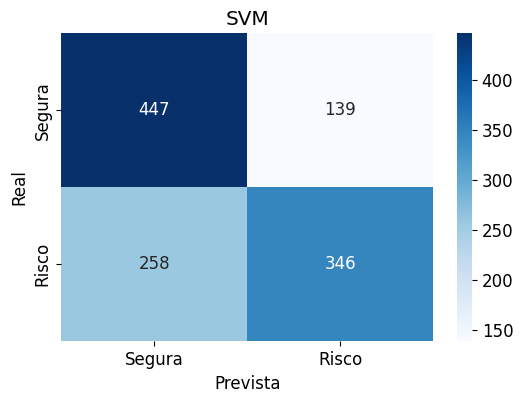

Árvore de Decisão - Acurácia: 0.6495798319327731


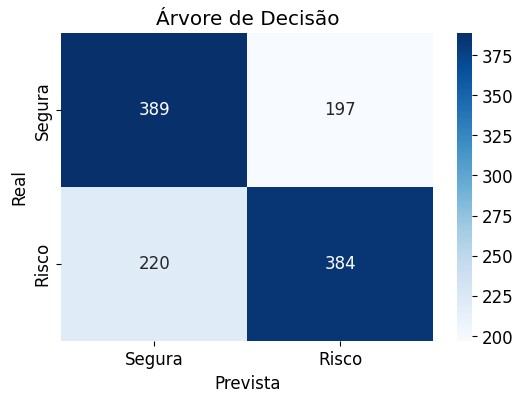

Floresta Aleatória - Acurácia: 0.7445378151260504


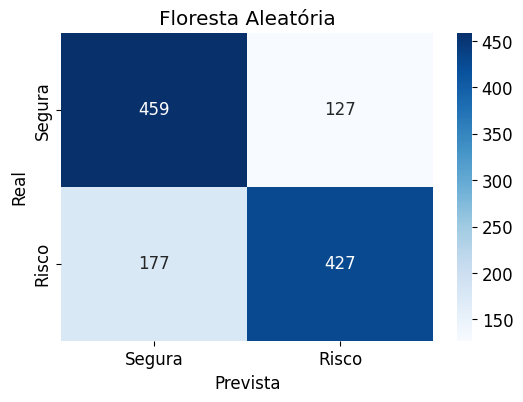

Rede Neural (MLP) - Acurácia: 0.7218487394957983


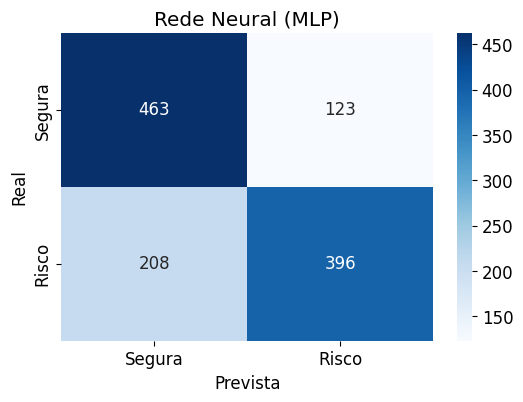

Classificador,Bloco,Floresta Aleatória,Rede Neural (MLP),Regressão Logística,SVM,Árvore de Decisão
0,Bloco 1,0.696474,0.656171,0.652393,0.643577,0.636020
1,Bloco 2,0.636822,0.651955,0.644388,0.654477,0.581337
2,Bloco 3,0.638083,0.622951,0.686003,0.728878,0.573770
3,Bloco 4,0.775536,0.746532,0.674653,0.675914,0.713745
4,Bloco 5,0.590164,0.648172,0.534678,0.547289,0.598991


In [71]:
aplicar_modelos_ml(df_ml, plot_cm=True)

---

# ▶ Redes Neurais ◀

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv1D, Flatten
from tensorflow.keras.layers import GRU
from tensorflow.keras.utils import plot_model
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

Melhor MLP

Melhores parâmetros: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate': 'constant', 'solver': 'adam'}

Resultados da Validação Cruzada:
Fold 1 - Acurácia: 0.9986
Acurácia do MLP no conjunto de teste: 1.0000


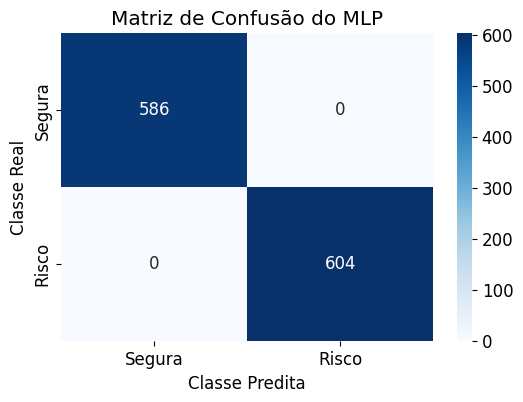

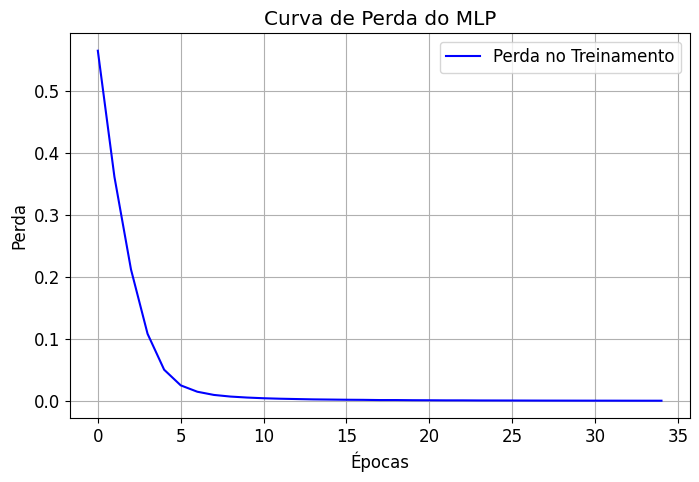

Acurácia no Treinamento: 1.0000
Acurácia no Teste: 1.0000


In [73]:
def preparar_dados_mlp(df):
    """
    Prepara os dados para a MLP, aplicando SMOTE e normalizando as features.
    """
    X = df.drop(columns=['manobra', 'id_route', 'id_trecho_curvo'])
    y = df['manobra']

    smote = SMOTE(random_state=42)
    X, y = smote.fit_resample(X, y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return train_test_split(X_scaled, y, test_size=0.3, random_state=42)

def treinar_mlp(X_train, X_test, y_train, y_test):
    """
    Treina um MLPClassifier com validação cruzada, otimização de hiperparâmetros e análise de overfitting.
    """
    param_grid = {
        'hidden_layer_sizes': [(128, 64)],
        'activation': ['relu'],
        'solver': ['adam'],
        'alpha': [0.0001],  # Regularização L2
        'learning_rate': ['constant']
    }

    mlp = MLPClassifier(max_iter=2000, random_state=42)

    grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='accuracy', n_jobs=-1, return_train_score=True)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    print(f"Melhores parâmetros: {grid_search.best_params_}")

    # Exibindo os resultados da validação cruzada
    cv_results = grid_search.cv_results_
    print("\nResultados da Validação Cruzada:")
    for i in range(len(cv_results['mean_test_score'])):
        print(f"Fold {i+1} - Acurácia: {cv_results['mean_test_score'][i]:.4f}")

    # Treinar o modelo otimizado
    best_model.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Acurácia do MLP no conjunto de teste: {accuracy:.4f}")

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Segura', 'Risco'],
                yticklabels=['Segura', 'Risco'])
    plt.title("Matriz de Confusão do MLP")
    plt.ylabel("Classe Real")
    plt.xlabel("Classe Predita")
    plt.show()

    # 📌 Análise de Overfitting 📌
    plt.figure(figsize=(8, 5))
    plt.plot(best_model.loss_curve_, label='Perda no Treinamento', color='blue')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.title('Curva de Perda do MLP')
    plt.legend()
    plt.grid()
    plt.show()

    train_accuracy = best_model.score(X_train, y_train)
    test_accuracy = best_model.score(X_test, y_test)

    print(f"Acurácia no Treinamento: {train_accuracy:.4f}")
    print(f"Acurácia no Teste: {test_accuracy:.4f}")

    # possível overfitting
    if train_accuracy - test_accuracy > 0.1:  # Diferença de 10% ou mais
        print("⚠️ Possível overfitting detectado! O modelo pode estar se ajustando demais ao treino.")

    return best_model

X_train, X_test, y_train, y_test = preparar_dados_mlp(df_ml)
modelo_mlp = treinar_mlp(X_train, X_test, y_train, y_test)

---

## Testando outros modelos de Redes Neurais

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,370 (40.51 KB)

 Trainable params: 10,370 (40.51 KB)

 Non-trainable params: 0 (0.00 B)

Treinando MLP com class_weight...
Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6808 - loss: 0.5875 - val_accuracy: 0.9640 - val_loss: 0.1991
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9336 - loss: 0.1862 - val_accuracy: 0.9892 - val_loss: 0.0623
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9754 - loss: 0.0789 - val_accuracy: 0.9946 - val_loss: 0.0350
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9899 - loss: 0.0469 - val_accuracy: 0.9910 - val_loss: 0.0444
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9948 - loss: 0.0185 - val_accuracy: 0.9928 - val_loss: 0.0434
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9980 - loss: 0.0130 - val_accuracy: 0.9946 - val_loss: 0.0298
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9945 - loss: 0.0157 - val_accuracy: 0.9964 - val_loss: 0.0188
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9940 - loss: 0.0232 

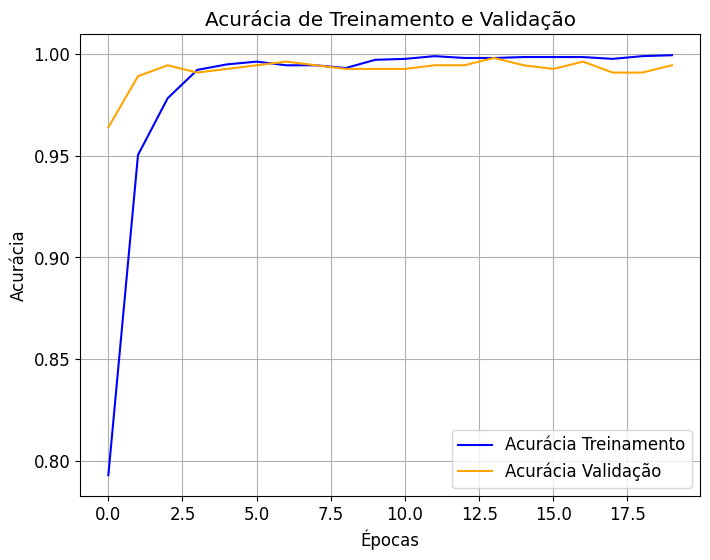

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Acurácia do MLP: 1.0


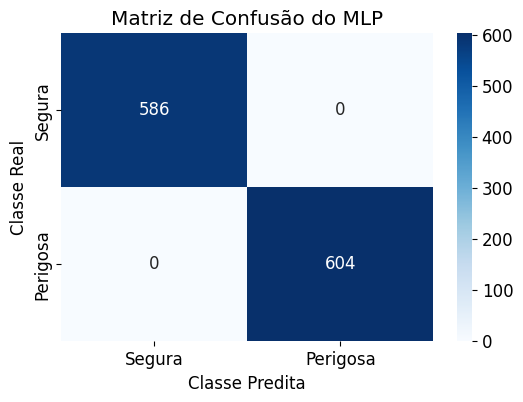

In [74]:
def preparar_dados_mlp(df):
    """
    Prepara os dados para a MLP, considerando o uso da SMOTE.
    """
    X = df.drop(columns=['manobra', 'id_route', 'id_trecho_curvo']).values
    y = df['manobra'].values

    smote = SMOTE(random_state=42)
    X, y = smote.fit_resample(X, y)

    # Padronizar os dados
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    y_categorical = to_categorical(y)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_categorical, test_size=0.3, random_state=42)

    return X_train, X_test, y_train, y_test

# modelo MLP
def construir_mlp(num_features):
    modelo = Sequential([
        Input(shape=(num_features,)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(2, activation='softmax')
    ])
    modelo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return modelo

# Preparação e treino do modelo MLP
X_train, X_test, y_train, y_test = preparar_dados_mlp(df_ml) # Estou usando as features estatisticas
modelo_mlp = construir_mlp(X_train.shape[1])

# Estrutura da rede
modelo_mlp.summary()

print("Treinando MLP com class_weight...")
history = modelo_mlp.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Acurácia Treinamento', color='blue')
plt.plot(history.history['val_accuracy'], label='Acurácia Validação', color='orange')
plt.title('Acurácia de Treinamento e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

# Avaliação no conjunto de teste
y_pred_proba = modelo_mlp.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_test_classes = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_test_classes, y_pred)

#print(y_pred_proba)
#print(y_pred)
#print(y_test_classes)

print(f"Acurácia do MLP: {accuracy}")

# MC
cm = confusion_matrix(y_test_classes, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Segura', 'Perigosa'],
            yticklabels=['Segura', 'Perigosa'])
plt.title("Matriz de Confusão do MLP")
plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.show()

Treinando GRU...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6667 - loss: 0.6761 - val_accuracy: 0.7785 - val_loss: 0.6593
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7802 - loss: 0.6537 - val_accuracy: 0.8014 - val_loss: 0.6375
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8202 - loss: 0.6305 - val_accuracy: 0.8447 - val_loss: 0.6103
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8497 - loss: 0.6021 - val_accuracy: 0.8676 - val_loss: 0.5749
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8850 - loss: 0.5609 - val_accuracy: 0.8813 - val_loss: 0.5315
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9154 - loss: 0.5126 - val_accuracy: 0.9041 - val_loss: 0.4824
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9361 - loss: 0.4571 - val_accuracy: 0.9361 - val_loss: 0.4268
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9633 - loss: 0.3925 - val_accuracy: 0.9498 - val_loss: 0.3696
Ep

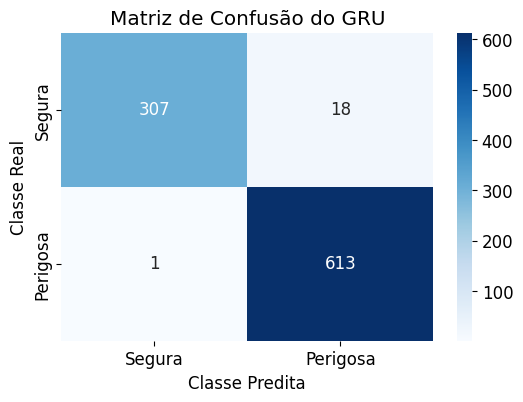

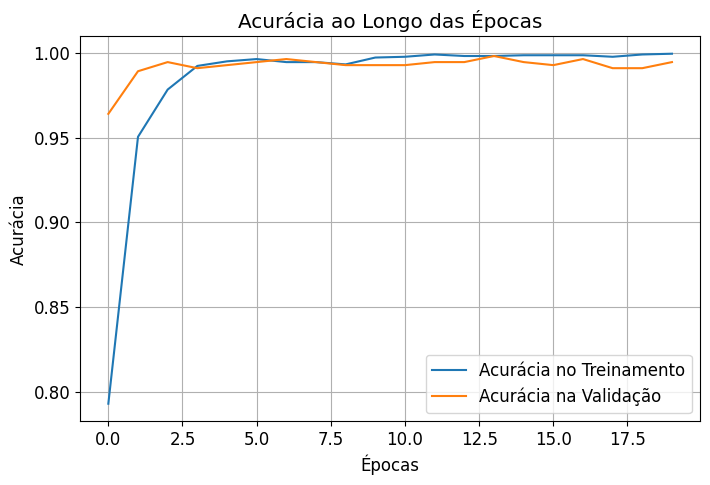

In [75]:
# Preparação dos dados para GRU
def preparar_dados_gru(df, janela_tempo=5):
    X = df.drop(columns=['manobra', 'id_route', 'id_trecho_curvo']).values
    y = to_categorical(df['manobra'].values)

    # Padronização
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Ajustar o tamanho dos dados para a entrada na GRU
    num_features = X_scaled.shape[1]
    num_samples = X_scaled.shape[0] // janela_tempo
    X_scaled = X_scaled[:num_samples * janela_tempo].reshape(num_samples, janela_tempo, num_features)
    y_scaled = y[:num_samples]

    # Dividir em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

    return X_train, X_test, y_train, y_test, num_features

# Definir e treinar o modelo GRU
def construir_gru(janela_tempo, num_features):
    """
    Constrói e treina um modelo GRU para classificação de manobras.
    """
    modelo = Sequential([
        GRU(3, input_shape=(janela_tempo, num_features), return_sequences=True),
        GRU(2),
        Dense(2, activation='softmax')
    ])
    modelo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return modelo

# Preparação e treino
janela_tempo = 1
X_train, X_test, y_train, y_test, num_features = preparar_dados_gru(df_ml, janela_tempo)
modelo_gru = construir_gru(janela_tempo, num_features)

print("Treinando GRU...")
modelo_gru.fit(X_train, y_train, epochs=10, batch_size=50, validation_split=0.2, verbose=1)
loss, accuracy = modelo_gru.evaluate(X_test, y_test, verbose=0)
cm = confusion_matrix(np.argmax(y_test, axis=1),
                      np.argmax(modelo_gru.predict(X_test), axis=1))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Segura', 'Perigosa'],
            yticklabels=['Segura', 'Perigosa'])
plt.title("Matriz de Confusão do GRU")
plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Acurácia no Treinamento')
plt.plot(history.history['val_accuracy'], label='Acurácia na Validação')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()